          x  y
0 -5.000000  0
1 -4.949749  0
2 -4.899497  0
3 -4.849246  0
4 -4.798995  0
Best solution (w, b): 5.0, -0.010229292300862003
Best fitness (MSE): 0.0076615823417755914


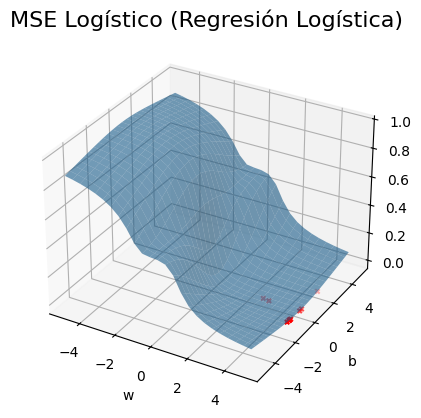

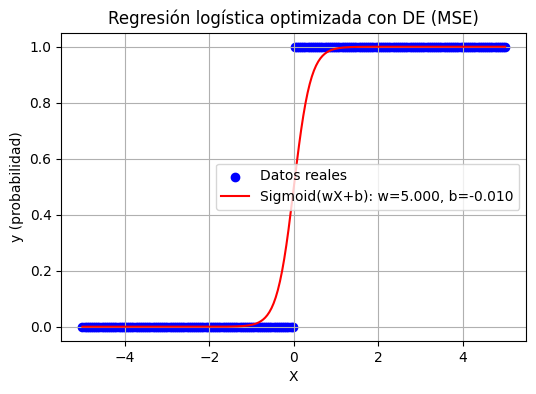

In [2]:
#######################################################################################
# Differential Evolution (DE) Algorithm #
# Authors: Jorge Galvez, UdG
# Modified: Christian Luna, UdG
#######################################################################################

# Import required libraries.
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import math

## cargamos los datos 
url = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/dataset_binario_Practica_3.csv"
df = pd.read_csv(url)

# Definimos X e y igual que antes
X = df.iloc[:, 0].astype(float).values   # primera columna
y = df.iloc[:, 1].astype(float).values   # segunda columna

# nornalizamos para la sigmoide

y = (y - y.min()) / (y.max() - y.min())

print(df.head())
# -----------------------------

# Sigmoide escalar estable (evita overflow para z muy grandes en valor absoluto)
def sigmoid_scalar(z):
    if z >= 0:
        ez = math.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = math.exp(z)
        return ez / (1.0 + ez)

# Fitness function definition.
# MSE de regresión logística = MSE(y, sigmoid(w*X + b)) 
def sphere(x):
     w, b = x[0, 0], x[0, 1]
     n = len(X)
     total = 0.0
     for i in range(n):
         z = w * X[i] + b
         sig = sigmoid_scalar(z)   # usa versión estable
         err = y[i] - sig
         total += err * err
     fit = total / n
     return fit

# Dimensiones: w y b
dimensions = 2

# Límites de búsqueda
t = np.array([-5, 5])
f_range = np.tile(t, (dimensions, 1))

# Iteraciones máximas
max_iter = 100

# Población
num_agents = 10
agents = np.zeros((num_agents, dimensions))

# Inicialización
for i in range(dimensions):
    dim_f_range = f_range[i, 1] - f_range[i, 0]
    agents[:, i] = np.random.rand(num_agents) * dim_f_range + f_range[i, 0]

best_position = np.zeros(dimensions)
best_fitness = np.nan
fitness = np.empty(num_agents)

# Evaluación inicial
for i in range(num_agents):
    fitness[i] = sphere(np.array([agents[i]]))
    if i == 0:
        best_position = agents[i]
        best_fitness = fitness[i]
    elif fitness[i] < best_fitness:
        best_position = agents[i]
        best_fitness = fitness[i]

# Iterador
iter = 1
aux_selector = np.arange(num_agents)

# Parámetros de DE
m = 0.7
cross_p = 0.5

# Gráfico inicial (3D superficie de MSE en logística)
if dimensions == 2:
    xGraph = np.linspace(-5, 5, 25)
    yGraph = np.linspace(-5, 5, 25)
    xv, yv = np.meshgrid(xGraph, yGraph)
    fitnessGraph = np.zeros((25, 25))
    for i in range(25):
        for j in range(25):
            arr = [[xv[i, j], yv[i, j]]]
            fitnessGraph[i, j] = sphere(np.asarray(arr))
    plt.ion()
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    plt.title('MSE Logístico (Regresión Logística)', fontsize=16)
    ax.plot_surface(xv, yv, fitnessGraph, alpha=0.6)
    ax.scatter(agents[:, 0], agents[:, 1], fitness[:], c='red', s=10, marker="x")
    fig.canvas.draw()
    fig.canvas.flush_events()
    time.sleep(0.000000001)

# Bucle principal de DE
while iter < max_iter:
    for i in range(agents.shape[0]):
        # Selección de 3 individuos distintos
        indexes = aux_selector[aux_selector != i]
        indexes = np.random.choice(indexes, 3, replace=False)
        agents_selected = agents[indexes]
        # Mutación diferencial
        mut = agents_selected[0] + m * (agents_selected[1] - agents_selected[2])
        # Cruce binario estándar
        prob_vector = np.random.rand(dimensions) <= cross_p
        mut = agents[i] * np.logical_not(prob_vector) + mut * prob_vector

        # Restringir dentro de los límites
        for j in range(dimensions):
            upper_limit = f_range[j, 1]
            lower_limit = f_range[j, 0]
            if mut[j] < lower_limit:
                mut[j] = lower_limit
            elif mut[j] > upper_limit:
                mut[j] = upper_limit

        # Evaluación del mutante
        fitness_mut = sphere(np.array([mut]))

        # Reemplazo
        if fitness_mut < fitness[i]:
            agents[i] = mut
            fitness[i] = fitness_mut
            if fitness[i] < best_fitness:
                best_position = agents[i]
                best_fitness = fitness[i]

        # Gráfico en tiempo real
        if dimensions == 2:
            plt.cla()
            ax.set_xlabel('w')
            ax.set_ylabel('b')
            plt.title('MSE Logístico (Regresión Logística)', fontsize=16)
            ax.plot_surface(xv, yv, fitnessGraph, alpha=0.6)
            ax.scatter(agents[:, 0], agents[:, 1], fitness[:], c='red', s=10, marker="x")
            fig.canvas.draw()
            fig.canvas.flush_events()
            time.sleep(0.000000001)

        iter = iter + 1
        # print("Iteration: " + str(iter))  

# Resultados finales
print("Best solution (w, b): " + str(best_position[0]) + ", "  + str(best_position[1]))
print("Best fitness (MSE): " + str(best_fitness))

# Visualización 2D (curva logística con w y b óptimos)
w_opt, b_opt = best_position[0], best_position[1]

# y_hat calculado de forma escalar 
y_hat = []
for xi in X:
    z = w_opt * xi + b_opt
    sig = sigmoid_scalar(z)
    y_hat.append(sig)
y_hat = np.array(y_hat)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue', label="Datos reales")
plt.plot(X, y_hat, color='red', label=f"Sigmoid(wX+b): w={w_opt:.3f}, b={b_opt:.3f}")
plt.xlabel("X")
plt.ylabel("y (probabilidad)")
plt.title("Regresión logística optimizada con DE (MSE)")
plt.legend()
plt.grid(True)
plt.show()


